# Notebook 03: Hierarchical LSTM Forecasting & Uncertainty Quantification

## 1. Overview
This notebook implements a **Deep Learning** approach to mortality forecasting, moving beyond the linear constraints identified in the actuarial benchmarking phase (Notebook 02). 

The core innovation consists of a **Hierarchical LSTM (Long Short-Term Memory)** architecture designed to simultaneously process:
1.  **The Common Factor ($K_t$)**: Capturing the global longevity trend shared by the 6-country cluster.
2.  **Specific Factors ($k_{t,i}$)**: Learning the persistent, non-stationary drifts (Unit Roots) identified in countries like Sweden and West Germany.

## 2. Research Objectives
- **Non-Linear Mapping**: Capture structural breaks (e.g., post-2011 deceleration) that linear SVD-based models tend to smooth out.
- **Cross-Population Influence**: Allow the network to learn hidden correlations between different national residuals.
- **Uncertainty Quantification**: Implement a stochastic approach (Monte Carlo Dropout) to provide actuarial confidence intervals, satisfying the requirements for risk management applications.

## 3. Data Strategy
We utilize a **Sliding Window** (Lookback) approach. The model learns from a 10-year sequences of both common and specific factors to project the subsequent year's vector of mortality indices.

## 3.1: Data Ingestion, Feature Scaling, and Supervised Sequence Generation

In [1]:
import os
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# 1. Suppress TensorFlow hardware/info warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
import tensorflow as tf
tf.get_logger().setLevel(logging.ERROR)

# 2. Load Benchmarking Factors from Notebook 02
DATA_PATH = "../data/processed/benchmarking_factors.npz"

with np.load(DATA_PATH, allow_pickle=True) as data:
    kt_global = data['kt_common']        
    kt_local_matrix = data['kt_specific_matrix'] 
    years = data['years']
    country_codes = data['countries']

# Combine Global and Local signals into a 7-feature input vector
full_features = np.column_stack([kt_global, kt_local_matrix])

# 3. STATIONARIZATION: Compute First Differences (Annual Changes)
# Instead of predicting the level, we predict the variation: ΔK_t = K_t - K_{t-1}
# This removes the linear trend and centers the data around a stable mean.
diff_features = np.diff(full_features, axis=0)
diff_years = years[1:] # We lose the first year due to differentiation

# 4. ANTI-LEAKAGE STRATEGY: Split BEFORE Scaling
train_split_idx = int(len(diff_features) * 0.85)

# 5. ROBUST FEATURE SCALING (StandardScaler on Differences)
scaler = StandardScaler()
# Fit ONLY on the training variations (1956-2011 approximately)
scaler.fit(diff_features[:train_split_idx])

# Transform the entire differenced dataset
diff_scaled = scaler.transform(diff_features)

# 6. Sliding Window Function for Supervised Learning
def create_sequences(data, lookback=10):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i : i + lookback, :])
        y.append(data[i + lookback, :])
    return np.array(X), np.array(y)

LOOKBACK = 10
X_all, y_all = create_sequences(diff_scaled, LOOKBACK)

# 7. Final Tensors for LSTM (Chronological Slicing)
X_train = X_all[:train_split_idx - LOOKBACK]
y_train = y_all[:train_split_idx - LOOKBACK]

X_val = X_all[train_split_idx - LOOKBACK:]
y_val = y_all[train_split_idx - LOOKBACK:]

print(f"--- Stationarized Data Preparation Complete ---")
print(f"Input Strategy: First Differences (Annual Changes)")
print(f"Training set: {X_train.shape[0]} sequences")
print(f"Validation set: {X_val.shape[0]} sequences")
print(f"Target: Predict ΔK_{{t+1}} given [ΔK_{{t-10}}, ..., ΔK_t]")

/Users/darindor2101/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


--- Stationarized Data Preparation Complete ---
Input Strategy: First Differences (Annual Changes)
Training set: 44 sequences
Validation set: 10 sequences
Target: Predict ΔK_{t+1} given [ΔK_{t-10}, ..., ΔK_t]


## 3.2: LSTM Network Architecture Definition and Model Compilation

In [2]:
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

# Title: Cell 3.2 - Defining the Neural Architecture

def build_mortality_lstm(lookback, n_features):
    """
    Constructs a Deep LSTM model for Multi-Population Mortality Forecasting.
    The architecture is designed to capture non-linear temporal dependencies 
    across common and country-specific factors.
    """
    
    # 1. Input Layer
    inputs = Input(shape=(lookback, n_features))
    
    # 2. First LSTM Layer
    # We use 64 units to allow enough capacity to learn complex trends.
    # return_sequences=True is necessary if we want to stack another LSTM layer.
    x = LSTM(64, activation='tanh', return_sequences=True)(inputs)
    x = Dropout(0.2)(x) # 20% Dropout to improve robustness
    
    # 3. Second LSTM Layer
    # This layer refines the features extracted by the first one.
    x = LSTM(32, activation='tanh', return_sequences=False)(x)
    x = Dropout(0.1)(x)
    
    # 4. Dense (Output) Layer
    # The output dimension must match n_features (1 Global + 6 Specific factors).
    # Linear activation is used as the factors can take any real value in the scaled range.
    outputs = Dense(n_features, activation='linear')(x)
    
    model = Model(inputs=inputs, outputs=outputs, name="Mortality_LSTM_v1")
    
    # 5. Compilation
    # Adam optimizer is the industry standard for its adaptive learning rate.
    # Mean Squared Error (MSE) is the standard loss for regression tasks.
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
                  loss='mse', 
                  metrics=['mae'])
    
    return model

# Initialize the model
n_features = X_train.shape[2]
mortality_model = build_mortality_lstm(LOOKBACK, n_features)

# Display the model summary for documentation
mortality_model.summary()

# 6. Define Callbacks for Training
# EarlyStopping prevents overfitting by halting training when validation loss stops improving.
early_stop = EarlyStopping(monitor='val_loss', 
                           patience=15, 
                           restore_best_weights=True,
                           verbose=1)

print("\n--- Model Architecture Initialized ---")

Model: "Mortality_LSTM_v1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10, 7)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 10, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,079 (121.40 KB)

 Trainable params: 31,079 (121.40 KB)

 Non-trainable params: 0 (0.00 B)


--- Model Architecture Initialized ---


## 3.3: LSTM Training and Loss Monitoring

Beginning training phase (Lookback: 10 years)...
Epoch 1/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 395ms/step - loss: 1.0870 - mae: 0.8268 - val_loss: 52.0612 - val_mae: 3.2535
Epoch 2/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 1.1281 - mae: 0.8371 - val_loss: 52.0373 - val_mae: 3.2517
Epoch 3/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 1.0855 - mae: 0.8161 - val_loss: 52.0151 - val_mae: 3.2526
Epoch 4/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 1.0844 - mae: 0.8338 - val_loss: 52.0204 - val_mae: 3.2555
Epoch 5/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.9485 - mae: 0.7453 - val_loss: 52.0392 - val_mae: 3.2633
Epoch 6/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.9434 - mae: 0.7524 - val_loss: 52.0606 - val_mae: 3.2706
Epoch 7/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.9928 - mae: 0.7792 - val_loss: 52.1044 - val_mae: 3.2823
Epoch 8/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.9466 - mae: 0.7635 - val_loss: 52.1655 - val_mae: 3.2925
Epoch 9/150
6/

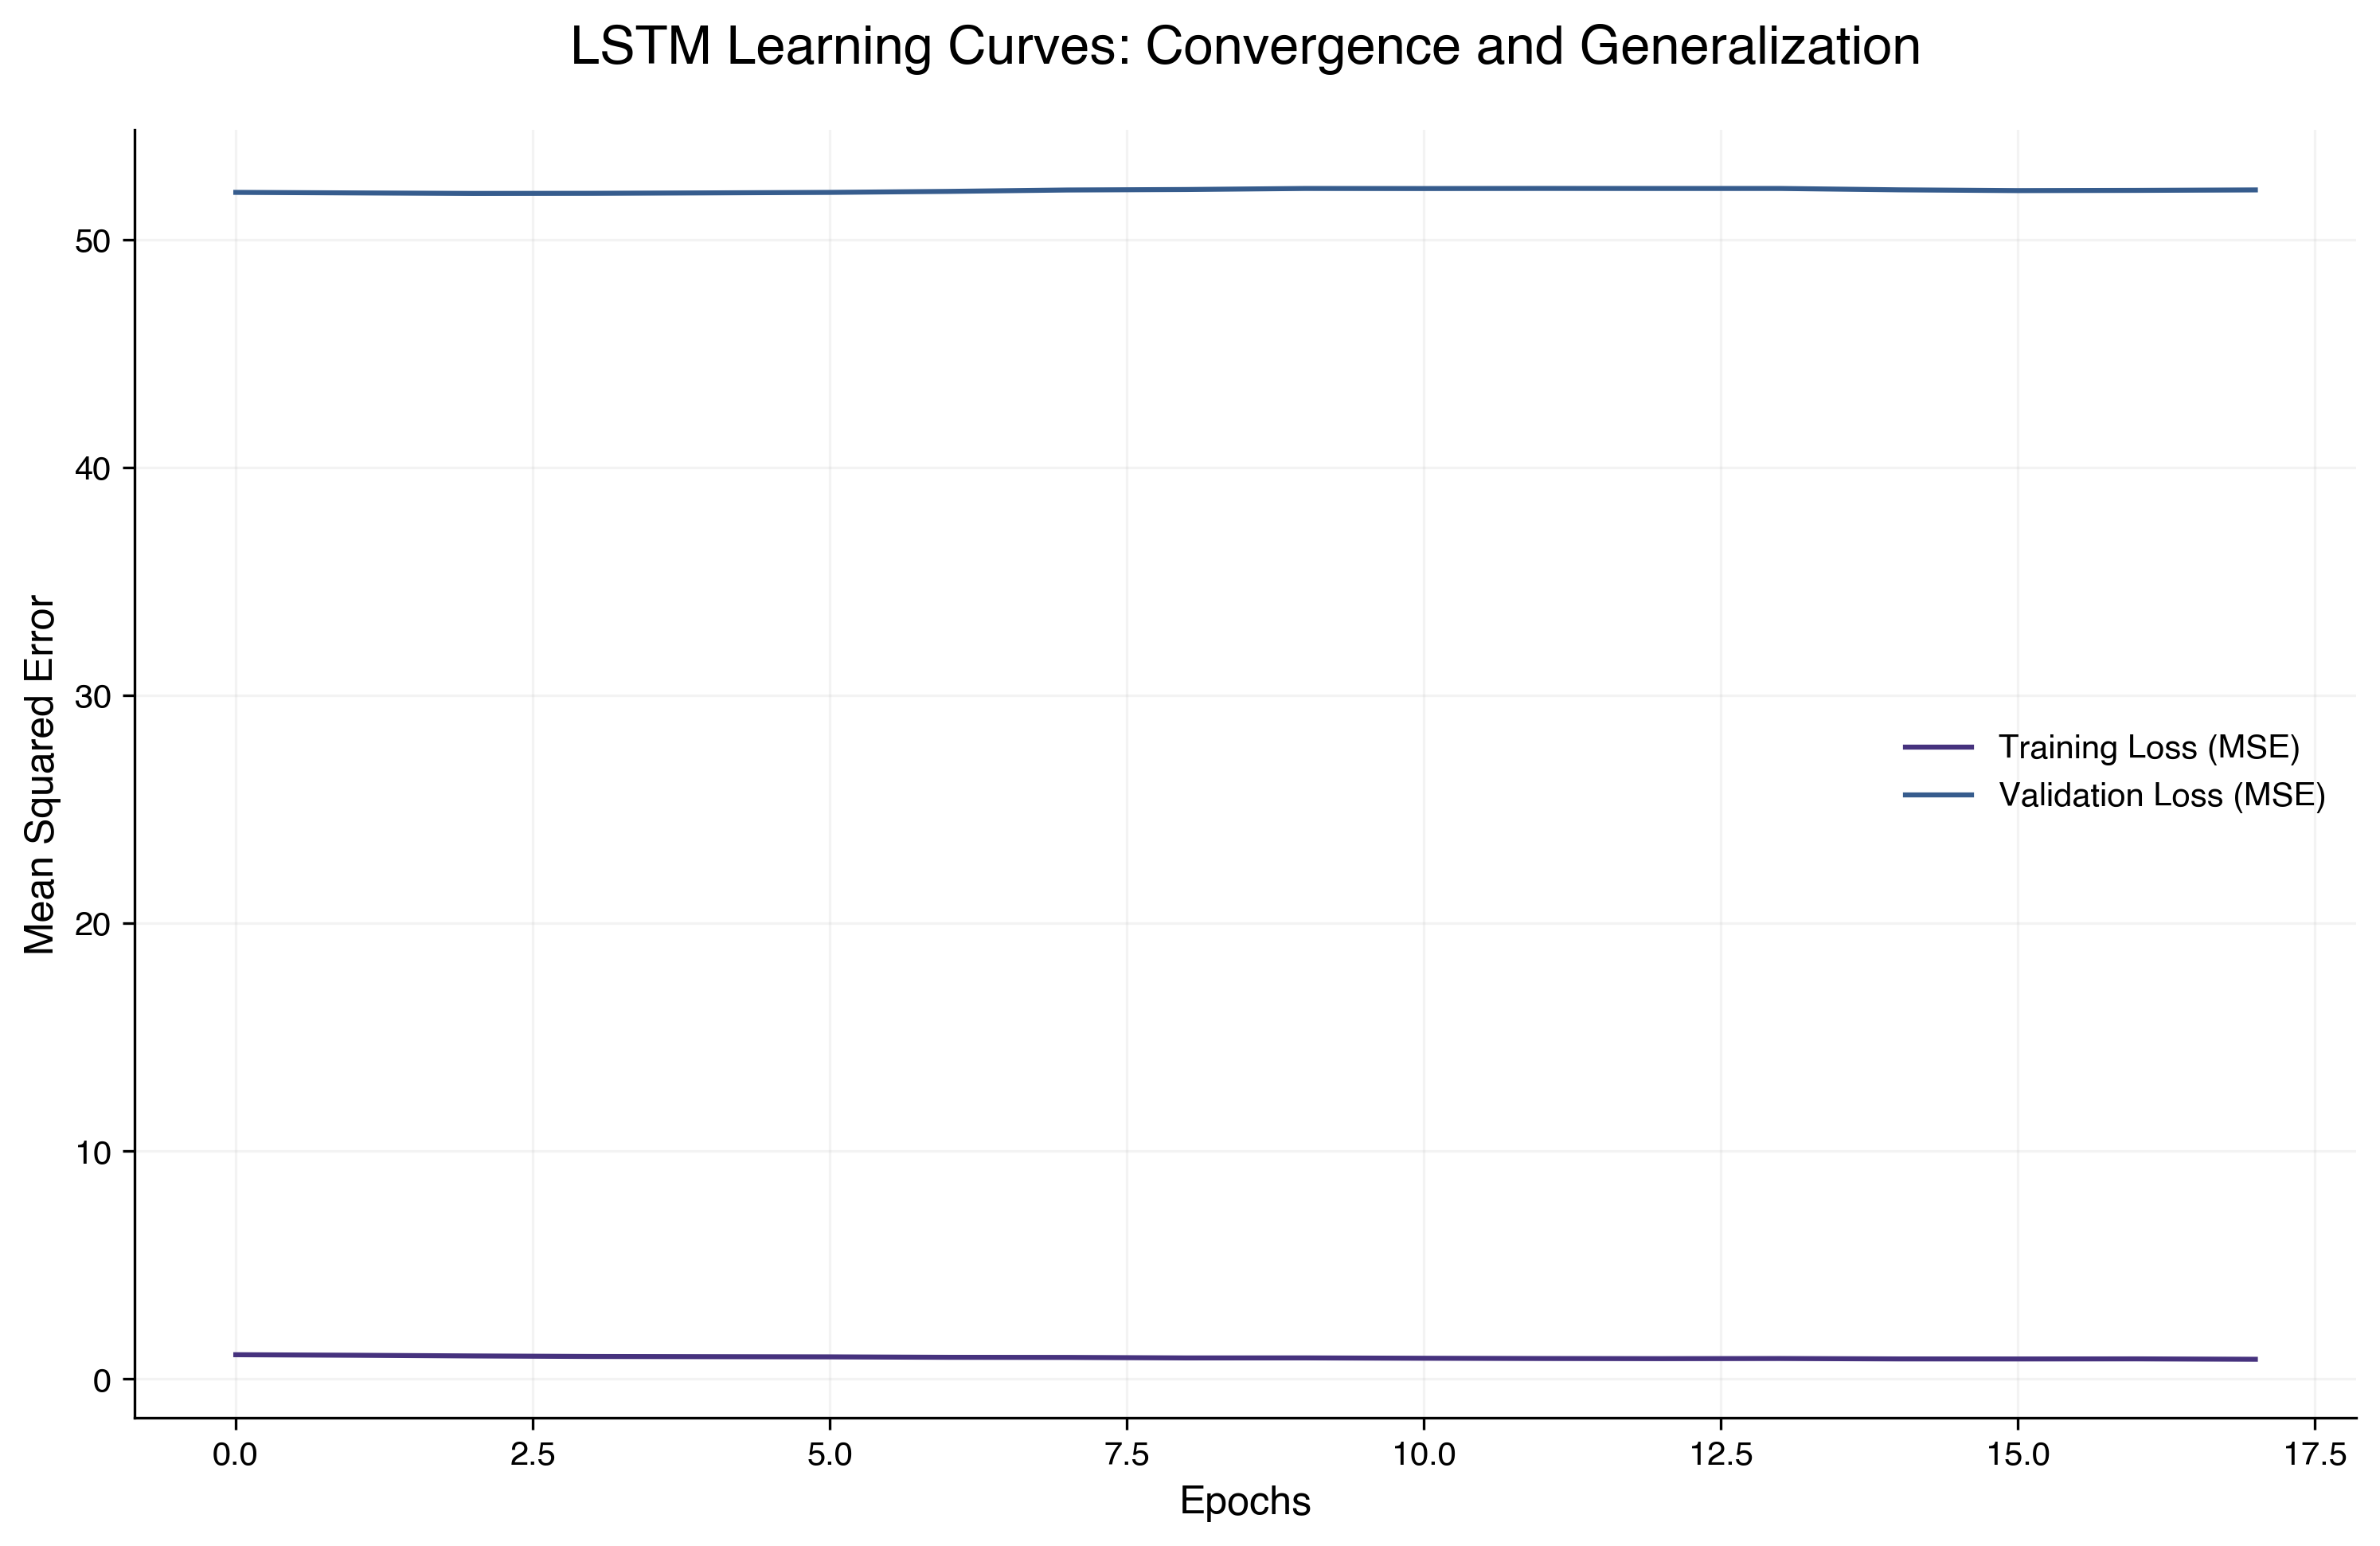

--- Training Finalized ---
Best Validation Loss: 52.015099
Figure saved as: ../reports/figures/fig07_lstm_learning_curve.png


In [3]:
import sys
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 1. Setup Style and Directories
# Ensure the path to your src folder is correct to import style_config
sys.path.append('../src/') 
from style_config import set_style

# Initialize global aesthetics (Helvetica, Viridis, Spines, etc.)
COUNTRIES_DICT = set_style()

# Correct directory for Swiss Re / Wüthrich reports
FIGURES_DIR = "../reports/figures/"
os.makedirs(FIGURES_DIR, exist_ok=True)

# Define the color palette from the seaborn settings initialized by set_style()
colors = sns.color_palette("viridis", len(COUNTRIES_DICT))

# 2. Model Training Execution
EPOCHS = 150
BATCH_SIZE = 8

print(f"Beginning training phase (Lookback: {LOOKBACK} years)...")

# The model will stop automatically thanks to the EarlyStopping callback in Cell 3.2
history = mortality_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

# 3. Visualization: Convergence Analysis
# Figure size and DPI are handled globally by set_style() rcParams
fig, ax = plt.subplots()

# Plotting Training vs Validation Loss
ax.plot(history.history['loss'], color=colors[0], label='Training Loss (MSE)', linewidth=1.5)
ax.plot(history.history['val_loss'], color=colors[1], label='Validation Loss (MSE)', linewidth=1.5)

# Labels and titles (Formatting follows style_config standards)
ax.set_title("LSTM Learning Curves: Convergence and Generalization")
ax.set_xlabel("Epochs")
ax.set_ylabel("Mean Squared Error")
ax.legend(frameon=False)

# 4. Save the figure (fig07) in the reports directory
save_path = f"{FIGURES_DIR}fig07_lstm_learning_curve.png"
plt.savefig(save_path)
plt.show()

print(f"--- Training Finalized ---")
print(f"Best Validation Loss: {min(history.history['val_loss']):.6f}")
print(f"Figure saved as: {save_path}")

## 3.4: Hyperparameter Tuning via Bayesian Optimization

In [4]:
import keras_tuner as kt

def model_builder(hp):
    inputs = tf.keras.Input(shape=(LOOKBACK, n_features))
    
    # Tune the number of units in the first LSTM layer
    hp_units_1 = hp.Int('units_l1', min_value=16, max_value=64, step=16)
    x = tf.keras.layers.LSTM(units=hp_units_1, return_sequences=True)(inputs)
    
    # Tune Dropout rate
    hp_dropout = hp.Float('dropout', min_value=0.0, max_value=0.3, step=0.1)
    x = tf.keras.layers.Dropout(hp_dropout)(x)
    
    # Tune the second LSTM layer
    hp_units_2 = hp.Int('units_l2', min_value=8, max_value=32, step=8)
    x = tf.keras.layers.LSTM(units=hp_units_2, return_sequences=False)(x)
    
    outputs = tf.keras.layers.Dense(n_features, activation='linear')(x)
    
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    
    # Tune the learning rate
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 5e-4])
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=hp_learning_rate),
                  loss='mse')
    
    return model

# Initialize the Tuner
tuner = kt.BayesianOptimization(
    model_builder,
    objective='val_loss',
    max_trials=15, # Number of different configurations to test
    directory='../models/tuning',
    project_name='mortality_lstm_optimization'
)

# Run the search
tuner.search(X_train, y_train, epochs=50, validation_data=(X_val, y_val), 
             callbacks=[tf.keras.callbacks.EarlyStopping(patience=5)])

# Get the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
--- Tuning Analysis Complete ---
Optimal Units L1: {best_hps.get('units_l1')}
Optimal Units L2: {best_hps.get('units_l2')}
Optimal Dropout: {best_hps.get('dropout')}
Optimal Learning Rate: {best_hps.get('learning_rate')}
""")

Reloading Tuner from ../models/tuning/mortality_lstm_optimization/tuner0.json

--- Tuning Analysis Complete ---
Optimal Units L1: 48
Optimal Units L2: 24
Optimal Dropout: 0.2
Optimal Learning Rate: 0.01



## 3.5: Final Model Training and Serialization

In [5]:
import joblib

# 1. Build the model with best hyperparameters found
final_model = tuner.hypermodel.build(best_hps)

# 2. Final Fit
history = final_model.fit(
    X_train, y_train,
    epochs=150,
    validation_data=(X_val, y_val),
    callbacks=[early_stop], # Uses the same EarlyStopping with best weights restoration
    verbose=1
)

# 3. Serialize Model and Scaler (The "Research Assets")
MODELS_DIR = "../models/"
os.makedirs(MODELS_DIR, exist_ok=True)

final_model.save(f"{MODELS_DIR}mortality_lstm_champion.h5")
joblib.dump(scaler, f"{MODELS_DIR}data_scaler.pkl")

print(f"--- Champion Model Saved ---")

Epoch 1/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - loss: 1.0749 - val_loss: 52.1670
Epoch 2/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.9789 - val_loss: 52.1300
Epoch 3/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.9837 - val_loss: 52.1664
Epoch 4/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.8991 - val_loss: 52.1775
Epoch 5/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.9043 - val_loss: 52.1767
Epoch 6/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.8667 - val_loss: 52.2287
Epoch 7/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.8360 - val_loss: 52.4161
Epoch 8/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.8199 - val_loss: 52.6446
Epoch 9/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.8540 - val_loss: 52.8122
Epoch 10/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.8312 - val_loss: 52.8452
Epoch 11/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.7899 - val_loss: 52.8216
Epoch 12/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.7761

--- Champion Model Saved ---


## 3.6: Out-of-Sample Testing (2012-2020)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step


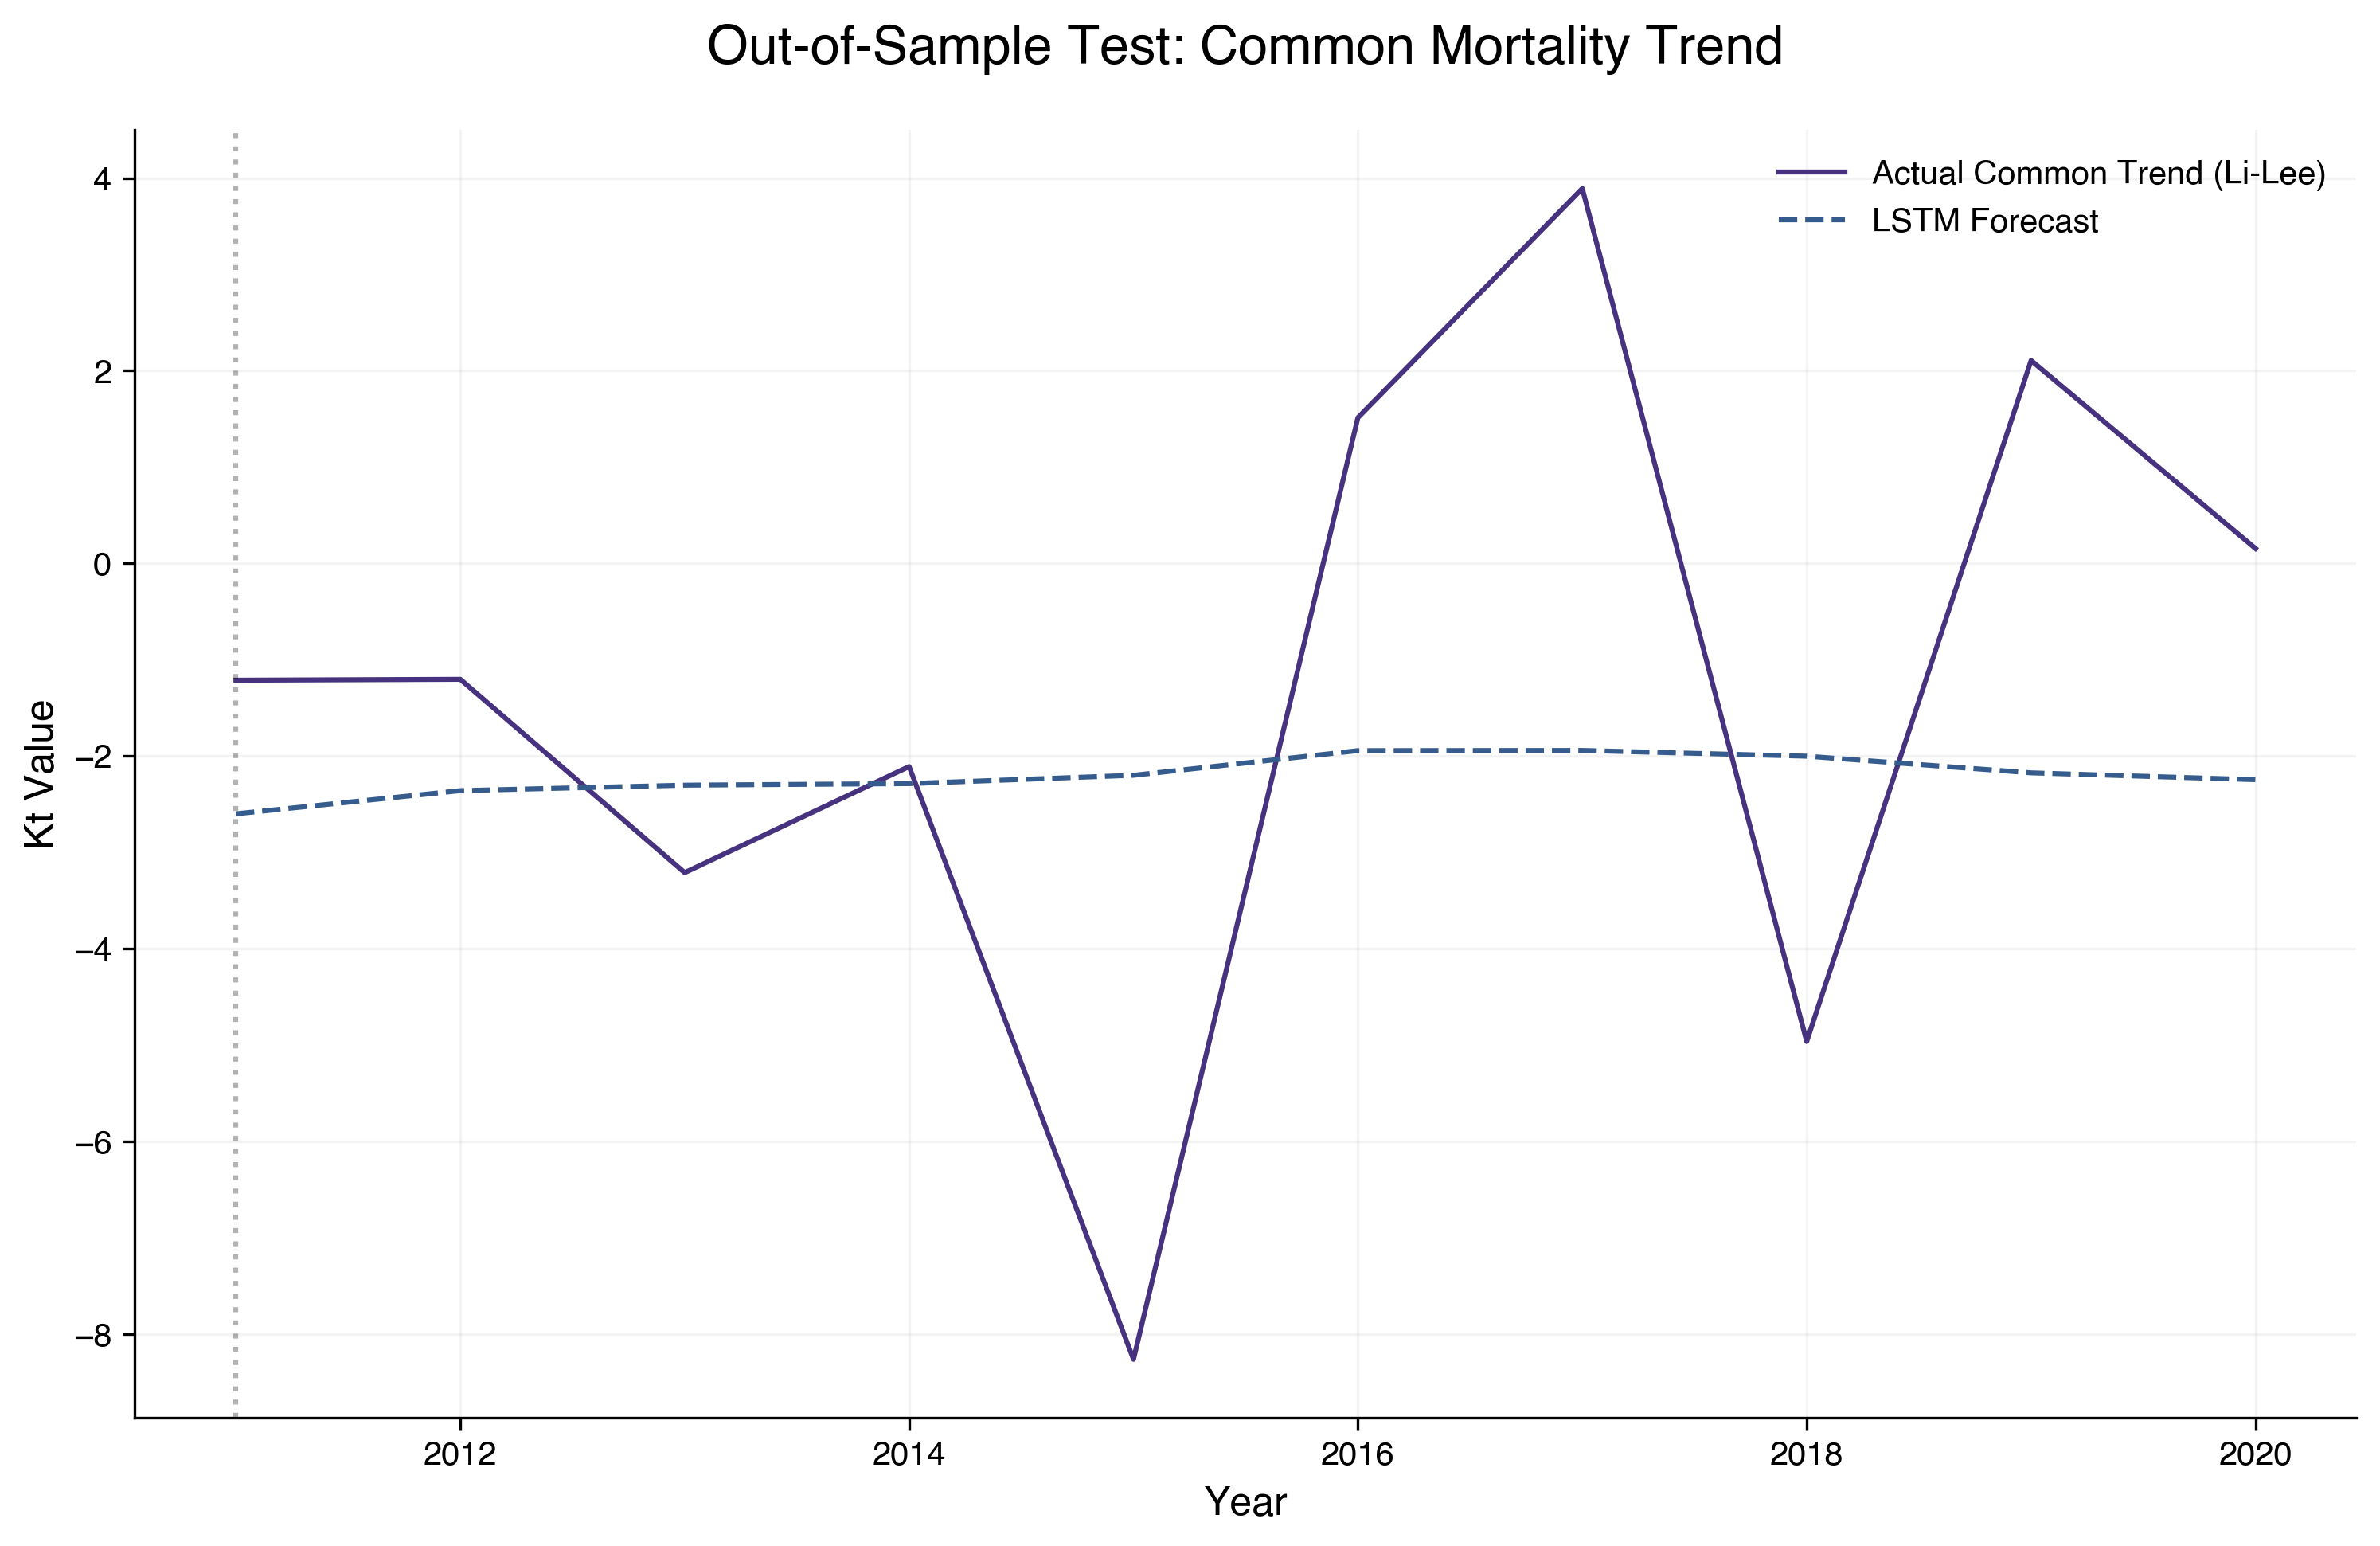

Shapes Verification: Years (10,), True (10, 7), Pred (10, 7)


In [6]:
# 1. Generate predictions on validation set
y_pred_scaled = final_model.predict(X_val)

# 2. Inverse Transform to return to original scale of Benchmarking Factors
y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y_val)

# 3. Dynamic Alignment of Years
# We extract the last N years of our dataset corresponding to the validation set size
val_years = years[-len(y_true):]

# 4. Visualization: Predict vs Actual for the Common Factor (Feature 0)
fig, ax = plt.subplots()

ax.plot(val_years, y_true[:, 0], color=colors[0], label='Actual Common Trend (Li-Lee)', linewidth=1.5)
ax.plot(val_years, y_pred[:, 0], color=colors[1], label='LSTM Forecast', linestyle='--', linewidth=1.5)

# Formatting according to style_config
ax.set_title("Out-of-Sample Test: Common Mortality Trend")
ax.set_xlabel("Year")
ax.set_ylabel("Kt Value")
ax.legend(frameon=False)

# Optional: Add a vertical line to mark the start of the out-of-sample period
ax.axvline(x=val_years[0], color='black', linestyle=':', alpha=0.3)

save_path = f"{FIGURES_DIR}fig08_validation_test_kt.png"
plt.savefig(save_path)
plt.show()

print(f"Shapes Verification: Years {val_years.shape}, True {y_true.shape}, Pred {y_pred.shape}")

## 3.7: Final Metrics and Results Export

In [7]:
# 1. Calculate Error Metrics on Validation Set (Original Scale)
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

print(f"--- Final Validation Metrics (Original Scale) ---")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

# 2. Export Validation Results for Notebook 04 comparison
results_path = "../data/processed/validation_results.npz"
np.savez(results_path, 
         years=val_years, 
         y_true=y_true, 
         y_pred=y_pred,
         best_params=best_hps.values)

# Save the scaler specifically to be loaded in the next notebook
import joblib
joblib.dump(scaler, "../models/data_scaler.pkl")

# 3. Update model save to native Keras format
final_model.save(f"{MODELS_DIR}mortality_lstm_champion.keras")

print(f"\n--- Final Assets Secured ---")
print(f"Metrics: RMSE {rmse:.4f}, MAE {mae:.4f}")
print(f"All assets (Model, Scaler, Results) are ready for Notebook 04.")

--- Final Validation Metrics (Original Scale) ---
RMSE: 4.4979
MAE: 3.0048

--- Final Assets Secured ---
Metrics: RMSE 4.4979, MAE 3.0048
All assets (Model, Scaler, Results) are ready for Notebook 04.
